In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
import plotly.express as px
from dash import Dash, dcc, html
from scipy.stats import pearsonr
import re

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
# Load the dataset
df = pd.read_csv("funko.csv")

# Check shape and first few rows
print(df.shape)
df.head()

(1482, 18)


,uid,title,product_type,price,interest,license,tags,vendor,form_factor,feature,related,description,gid,created_at,published_at,updated_at,handle,img
0,7051374362813,"""It's Crunch Time "" Kids Tee - General Mills",Apparel,7.0,['Ad Icons'],['General Mills'],"['Apparel', 'Cereal Day', 'Kids Tee', 'Markdow...",Funko Pop Up Shop,[],[],"['7051374788797', '7051374854333', '7051374723...","<p>""It's Crunch Time"" with the Count Chocula P...",gid://shopify/Product/7051374362813,2021-10-29T00:02:52-00:00,2021-10-29T16:30:00-00:00,2022-05-23T16:50:36-00:00,ad-icons-general-mills-its-crunch-time-kids-bl...,https://cdn.shopify.com/s/files/1/1052/2158/pr...
1,7231381405885,"""This is the Way"" Kids Tee - The Mandalorian",Apparel,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'Kids Tee', 'May the 4th', 'May th...",Funko Shop,[],[],"['7254814130365', '7254814064829', '4491928240...",<p>Celebrate May the Fourth in stellar style w...,gid://shopify/Product/7231381405885,2022-05-03T20:57:34-00:00,2022-05-04T15:30:00-00:00,2022-05-27T13:25:49-00:00,star-wars-this-is-the-way-kids-purple-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...
2,7231381536957,"""This is the Way"" Neon Blast Kids Tee - The Ma...",Apparel,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'May the 4th', 'May the 4th Be Wit...",Funko Shop,[],[],"['7254814130365', '7254814064829', '4491928240...",<p>Celebrate May the Fourth in stellar style w...,gid://shopify/Product/7231381536957,2022-05-03T20:57:40-00:00,2022-05-04T15:30:01-00:00,2022-05-29T18:15:32-00:00,star-wars-the-mandalorian-this-is-the-way-kids...,https://cdn.shopify.com/s/files/1/1052/2158/pr...
3,7051374395581,"""Time for a Midnight Bite"" Tee - General Mills",Apparel,14.0,['Ad Icons'],['General Mills'],"['Apparel', 'Cereal Day', 'Markdown Item', 'Sa...",Funko Pop Up Shop,[],[],"['7051374788797', '7051374854333', '7051374723...","<p>Like the Pop! Tee says, it's ""Time for a Mi...",gid://shopify/Product/7051374395581,2021-10-29T00:02:57-00:00,2021-10-29T16:30:01-00:00,2022-05-26T04:04:45-00:00,ad-icons-general-mills-midnight-bite-black-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...
4,7231381668029,"""Where He Goes, I Go"" Grogu Kids Tee - The Man...",Apparel,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'May the 4th', 'May the 4th Be Wit...",Funko Shop,[],[],"['7254814130365', '7254814064829', '4491928240...",<p>Celebrate May the Fourth in stellar style w...,gid://shopify/Product/7231381668029,2022-05-03T20:57:45-00:00,2022-05-04T15:30:02-00:00,2022-05-30T02:40:26-00:00,star-wars-where-he-goes-i-go-grogu-kids-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...


In [4]:
# inspect the column types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482 entries, 0 to 1481
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   uid           1482 non-null   int64  
 1   title         1482 non-null   object 
 2   product_type  1482 non-null   object 
 3   price         1482 non-null   float64
 4   interest      1482 non-null   object 
 5   license       1482 non-null   object 
 6   tags          1482 non-null   object 
 7   vendor        1482 non-null   object 
 8   form_factor   1482 non-null   object 
 9   feature       1482 non-null   object 
 10  related       1482 non-null   object 
 11  description   1482 non-null   object 
 12  gid           1482 non-null   object 
 13  created_at    1482 non-null   object 
 14  published_at  1482 non-null   object 
 15  updated_at    1482 non-null   object 
 16  handle        1482 non-null   object 
 17  img           1482 non-null   object 
dtypes: float64(1), int64(1), obj

In [5]:
# # ---------- CONFIG ----------
MULTI_COLS = ["interest", "license", "tags"]     # columns that have list-like strings
DATE_COLS  = ["created_at", "published_at", "updated_at"]  # adjust to your schema
DROP_COLS  = ["gid", "handle", "img"]            # optional drops if present

In [6]:
# Remove whitespace from all string cells
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()

In [7]:
# Remove HTML from description

if "description" in df.columns:
    # remove any HTML tags
    df["description"] = df["description"].astype(str).str.replace(r"<.*?>", "", regex=True).str.strip()

In [8]:
# Convert to datetime and strip the time component
for c in [col for col in DATE_COLS if col in df.columns]:
    # 1. Convert to datetime objects (handling the timezone automatically)
    # 2. Extract only the date part using .dt.date
    df[c] = pd.to_datetime(df[c], errors="coerce").dt.date

In [9]:
# Inspect form_factor column values
# Check if each entry is a list and has a length greater than 0
is_not_empty = df['form_factor'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)

# Count the occurrences of True (not empty) and False (empty)
counts = is_not_empty.value_counts()

# Display the results
print(f"Empty arrays: {counts.get(False, 0)}")
print(f"Arrays with elements: {counts.get(True, 0)}")

Empty arrays: 1482
Arrays with elements: 0


In [10]:
# All values of this column are empty arrays, so this column is unnecessary, so we can remove it

df.drop(columns=["form_factor"], axis=1, inplace=True)

In [11]:
df

,uid,title,product_type,price,interest,license,tags,vendor,feature,related,description,gid,created_at,published_at,updated_at,handle,img
0,7051374362813,"""It's Crunch Time "" Kids Tee - General Mills",Apparel,7.0,['Ad Icons'],['General Mills'],"['Apparel', 'Cereal Day', 'Kids Tee', 'Markdow...",Funko Pop Up Shop,[],"['7051374788797', '7051374854333', '7051374723...","""It's Crunch Time"" with the Count Chocula Pop!...",gid://shopify/Product/7051374362813,2021-10-29,2021-10-29,2022-05-23,ad-icons-general-mills-its-crunch-time-kids-bl...,https://cdn.shopify.com/s/files/1/1052/2158/pr...
1,7231381405885,"""This is the Way"" Kids Tee - The Mandalorian",Apparel,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'Kids Tee', 'May the 4th', 'May th...",Funko Shop,[],"['7254814130365', '7254814064829', '4491928240...",Celebrate May the Fourth in stellar style with...,gid://shopify/Product/7231381405885,2022-05-03,2022-05-04,2022-05-27,star-wars-this-is-the-way-kids-purple-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...
2,7231381536957,"""This is the Way"" Neon Blast Kids Tee - The Ma...",Apparel,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'May the 4th', 'May the 4th Be Wit...",Funko Shop,[],"['7254814130365', '7254814064829', '4491928240...",Celebrate May the Fourth in stellar style with...,gid://shopify/Product/7231381536957,2022-05-03,2022-05-04,2022-05-29,star-wars-the-mandalorian-this-is-the-way-kids...,https://cdn.shopify.com/s/files/1/1052/2158/pr...
3,7051374395581,"""Time for a Midnight Bite"" Tee - General Mills",Apparel,14.0,['Ad Icons'],['General Mills'],"['Apparel', 'Cereal Day', 'Markdown Item', 'Sa...",Funko Pop Up Shop,[],"['7051374788797', '7051374854333', '7051374723...","Like the Pop! Tee says, it's ""Time for a Midni...",gid://shopify/Product/7051374395581,2021-10-29,2021-10-29,2022-05-26,ad-icons-general-mills-midnight-bite-black-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...
4,7231381668029,"""Where He Goes, I Go"" Grogu Kids Tee - The Man...",Apparel,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'May the 4th', 'May the 4th Be Wit...",Funko Shop,[],"['7254814130365', '7254814064829', '4491928240...",Celebrate May the Fourth in stellar style with...,gid://shopify/Product/7231381668029,2022-05-03,2022-05-04,2022-05-30,star-wars-where-he-goes-i-go-grogu-kids-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477,6958000734397,Zombie Hunter Spidey - What If…?,Pop!,12.0,['Marvel'],"['Spider-Man', 'What If']","['Disney Plus', 'FFCBDAY', 'Gift Box', 'Gift G...",Funko Shop,['Back In Stock'],"['6218636001469', '7078124683453', '7193953960...","In the endless possibilities, venture to wonde...",gid://shopify/Product/6958000734397,2021-09-09,2022-05-26,2022-05-31,marvel-what-if-zombie-hunter-spidey-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...
1478,6958000963773,Zombie Iron Man - What If…?,Pop!,12.0,['Marvel'],"['Iron Man', 'What If']","['Disney Plus', 'FFCBDAY', 'Gift Box', 'Gift G...",Funko Shop,[],"['6958000734397', '7078124683453', '6924450332...","In the endless possibilities, venture to wonde...",gid://shopify/Product/6958000963773,2021-09-09,2021-11-22,2022-05-31,marvel-what-if-zombie-iron-man-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...
1479,7232416514237,Zorro,Pop!,12.0,['Classics'],['Zorro'],"['FFCBDAY', 'Gift Box', 'NOTIFY', 'PPP']",Funko Shop,['Coming Soon'],"['6161453613245', '7193953599677', '7239037386...","Celebrate the 65th Anniversary of Zorro, the o...",gid://shopify/Product/7232416514237,2022-05-04,2022-05-05,2022-05-05,tv-zorro-65th-anniversary-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...
1480,6192471605437,Zuko - Avatar: The Last Airbender,Pop!,12.0,['Anime'],['Avatar The Last Airbender'],"['Chase', 'FEB032022', 'FFCBDAY', 'Gift Box', ...",Funko Shop,"['Best Sellers', 'Chance of Chase']","['6192469999805', '6192471867581', '7087723282...","""I must capture the Avatar."" Zuko, prince to t...",g

In [12]:
# We should do the same for 'feature' column
# Check if each entry is a list and has a length greater than 0
is_not_empty_feature_column = df['feature'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)

# Count the occurrences of True (not empty) and False (empty)
counts = is_not_empty_feature_column.value_counts()

# Display the results
print(f"Empty arrays: {counts.get(False, 0)}")
print(f"Arrays with elements: {counts.get(True, 0)}")

Empty arrays: 1482
Arrays with elements: 0


In [13]:
# This column is also empty, so we can safely to drop it

df.drop(columns=["feature"], axis=1, inplace=True)

In [14]:
# Now we need to check if we use the uid column as the primary key column

isColumnUnique = df["uid"].is_unique

isColumnUnique

True

In [15]:
# After the check above, we can be sure that it is safe to use the id column as the primary key column

df.set_index('uid', inplace=True)

In [16]:
df

,title,product_type,price,interest,license,tags,vendor,related,description,gid,created_at,published_at,updated_at,handle,img
uid,,,,,,,,,,,,,,,
7051374362813,"""It's Crunch Time "" Kids Tee - General Mills",Apparel,7.0,['Ad Icons'],['General Mills'],"['Apparel', 'Cereal Day', 'Kids Tee', 'Markdow...",Funko Pop Up Shop,"['7051374788797', '7051374854333', '7051374723...","""It's Crunch Time"" with the Count Chocula Pop!...",gid://shopify/Product/7051374362813,2021-10-29,2021-10-29,2022-05-23,ad-icons-general-mills-its-crunch-time-kids-bl...,https://cdn.shopify.com/s/files/1/1052/2158/pr...
7231381405885,"""This is the Way"" Kids Tee - The Mandalorian",Apparel,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'Kids Tee', 'May the 4th', 'May th...",Funko Shop,"['7254814130365', '7254814064829', '4491928240...",Celebrate May the Fourth in stellar style with...,gid://shopify/Product/7231381405885,2022-05-03,2022-05-04,2022-05-27,star-wars-this-is-the-way-kids-purple-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...
7231381536957,"""This is the Way"" Neon Blast Kids Tee - The Ma...",Apparel,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'May the 4th', 'May the 4th Be Wit...",Funko Shop,"['7254814130365', '7254814064829', '4491928240...",Celebrate May the Fourth in stellar style with...,gid://shopify/Product/7231381536957,2022-05-03,2022-05-04,2022-05-29,star-wars-the-mandalorian-this-is-the-way-kids...,https://cdn.shopify.com/s/files/1/1052/2158/pr...
7051374395581,"""Time for a Midnight Bite"" Tee - General Mills",Apparel,14.0,['Ad Icons'],['General Mills'],"['Apparel', 'Cereal Day', 'Markdown Item', 'Sa...",Funko Pop Up Shop,"['7051374788797', '7051374854333', '7051374723...","Like the Pop! Tee says, it's ""Time for a Midni...",gid://shopify/Product/7051374395581,2021-10-29,2021-10-29,2022-05-26,ad-icons-general-mills-midnight-bite-black-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...
7231381668029,"""Where He Goes, I Go"" Grogu Kids Tee - The Man...",Apparel,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'May the 4th', 'May the 4th Be Wit...",Funko Shop,"['7254814130365', '7254814064829', '4491928240...",Celebrate May the Fourth in stellar style with...,gid://shopify/Product/7231381668029,2022-05-03,2022-05-04,2022-05-30,star-wars-where-he-goes-i-go-grogu-kids-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6958000734397,Zombie Hunter Spidey - What If…?,Pop!,12.0,['Marvel'],"['Spider-Man', 'What If']","['Disney Plus', 'FFCBDAY', 'Gift Box', 'Gift G...",Funko Shop,"['6218636001469', '7078124683453', '7193953960...","In the endless possibilities, venture to wonde...",gid://shopify/Product/6958000734397,2021-09-09,2022-05-26,2022-05-31,marvel-what-if-zombie-hunter-spidey-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...
6958000963773,Zombie Iron Man - What If…?,Pop!,12.0,['Marvel'],"['Iron Man', 'What If']","['Disney Plus', 'FFCBDAY', 'Gift Box', 'Gift G...",Funko Shop,"['6958000734397', '7078124683453', '6924450332...","In the endless possibilities, venture to wonde...",gid://shopify/Product/6958000963773,2021-09-09,2021-11-22,2022-05-31,marvel-what-if-zombie-iron-man-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...
7232416514237,Zorro,Pop!,12.0,['Classics'],['Zorro'],"['FFCBDAY', 'Gift Box', 'NOTIFY', 'PPP']",Funko Shop,"['6161453613245', '7193953599677', '7239037386...","Celebrate the 65th Anniversary of Zorro, the o...",gid://shopify/Product/7232416514237,2022-05-04,2022-05-05,2022-05-05,tv-zorro-65th-anniversary-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...


In [17]:
# 1. Remove double quotes, single quotes and specific special characters
# 2. Strip leading/trailing whitespaces
df['title'] = (
    df['title']
    .str.replace(r'[\"\'\-]', '', regex=True) # Removes ", ' and -
    .str.strip()                             # Removes spaces at the beginning and end
)

In [18]:
# Do the same for description field

df['description'] = (
    df['description']
    .str.replace(r'[\"\'\-]', '', regex=True) # Removes ", ' and -
    .str.strip()                             # Removes spaces at the beginning and end
)

In [19]:
# Now we need to cast list comumns to real lists, because now they are strings

def safe_literal_eval(val):
    """
    Safely convert string representation of a list into an actual Python list.
    Handles cases where data might already be a list or is NaN/None.
    """
    if isinstance(val, str) and val.startswith('['):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return [] # Return empty list if parsing fails
    elif isinstance(val, list):
        return val
    else:
        return [] # Return empty list for NaN or unexpected types

# Apply the conversion to each column in MULTI_COLS
for col in [c for c in MULTI_COLS if c in df.columns]:
    df[col] = df[col].apply(safe_literal_eval)

In [20]:
# In the future, I would like to make statisctics about chase figures
# Note: chase fugire is like rear version of normal figure. It's deferent, but when you buy normal figure, there is about 20% chance to receive chase version of the figure instead of the normal version

# Create a new boolean column 'is_chase'
# We iterate through each list in 'tags' and check if 'chase' exists in any form
df['is_chase'] = df['tags'].apply(
    lambda tags_list: any('chase' in str(tag).lower() for tag in tags_list) 
    if isinstance(tags_list, list) else False
)

In [21]:
# Calculate the percentage of Chase figures
# .mean() on a boolean column gives the ratio of True values (e.g., 0.15 for 15%)
chase_percentage = df['is_chase'].mean() * 100

# Calculate absolute counts for better context
total_count = len(df)
chase_count = df['is_chase'].sum()

print(f"Total items: {total_count}")
print(f"Chase items: {chase_count}")
print(f"Percentage of Chase figures: {chase_percentage:.2f}%")

Total items: 1482
Chase items: 100
Percentage of Chase figures: 6.75%


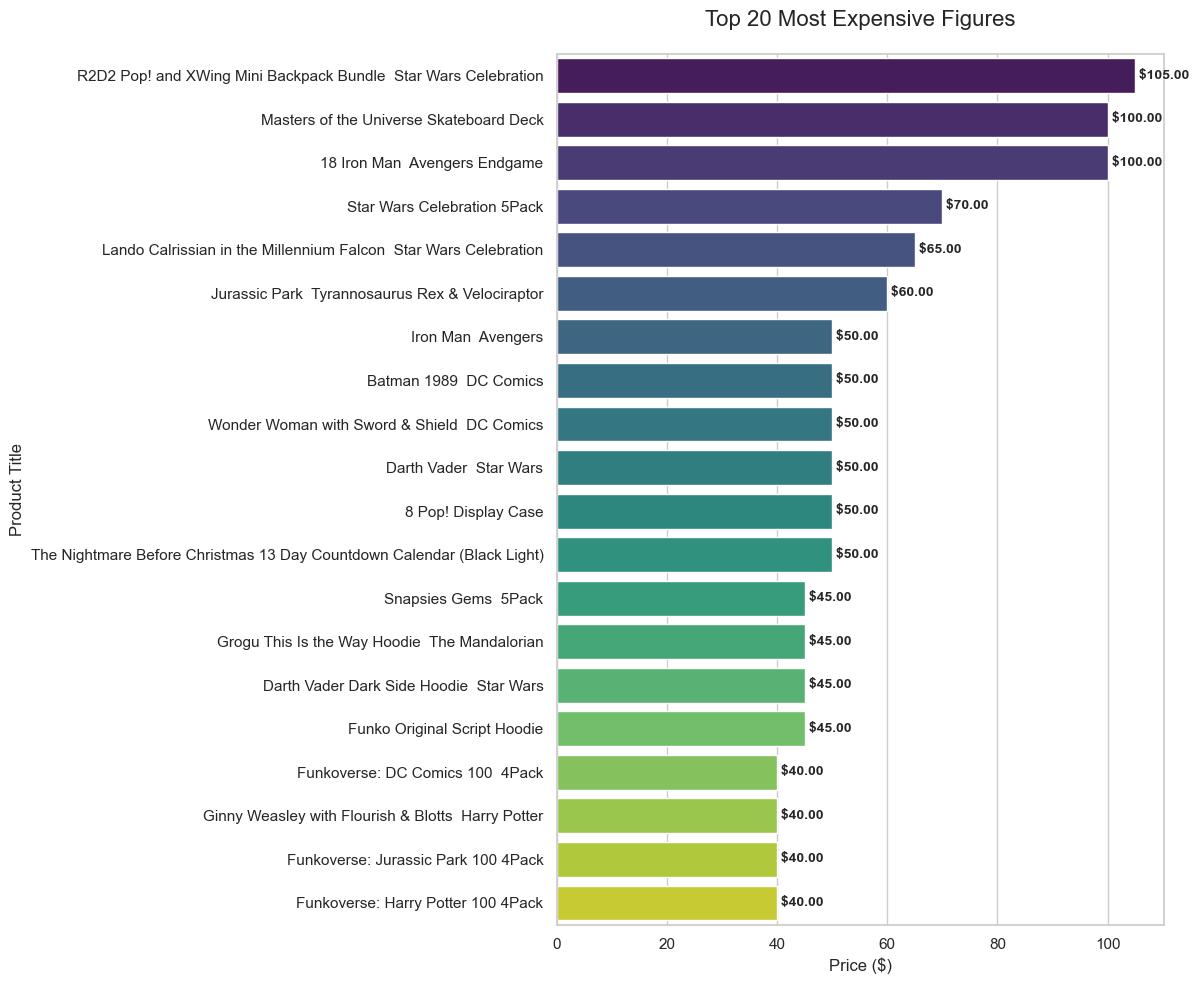

In [22]:
# Now lets check the top 20 most expensive figures

# 1. Sort by price descending and take the top 20
top_20_expensive = df.sort_values(by='price', ascending=False).head(20)

# 2. Set the visual style
plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# 3. Create the barplot
# Assigning y to hue and setting legend=False to fix the FutureWarning
# Using 'is_chase' for hue to visually distinguish Chase items
plot = sns.barplot(
    data=top_20_expensive,
    x='price',
    y='title',
    hue='title',      # Assigning y variable to hue as requested by Seaborn
    palette='viridis',
    legend=False      # Removes the redundant legend
)

# 4. Add labels and title
plt.title('Top 20 Most Expensive Figures', fontsize=16, pad=20)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Product Title', fontsize=12)

# 5. Add price labels at the end of each bar
for i, price in enumerate(top_20_expensive['price']):
    if not pd.isna(price):
        plt.text(price, i, f' ${price:,.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
top_20_expensive

,title,product_type,price,interest,license,tags,vendor,related,description,gid,created_at,published_at,updated_at,handle,img,is_chase
uid,,,,,,,,,,,,,,,,
7254814228669,R2D2 Pop! and XWing Mini Backpack Bundle Star...,Pop! & Bag,105.0,[Star Wars],[Star Wars],"[Backpack, Bag, Bundle, Diamond Collection, EX...",Funko Pop Up Shop,"['7254814130365', '7254814064829', '4491928240...",Soar through the day with ease with this Funko...,gid://shopify/Product/7254814228669,2022-05-26,2022-05-27,2022-05-29,star-wars-celebration-r2-d2-pop-and-x-wing-min...,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
7248075129021,Masters of the Universe Skateboard Deck,Skateboard,100.0,"[Cartoon Classics, Retro Toys]",[Masters of the Universe],"[EXCLUSIVE, Game Stop, Review Stock]",NoEmpDiscount,"['6953667395773', '6127454060733', '4540283748...",Decide the fate of Eterna in your Masters of t...,gid://shopify/Product/7248075129021,2022-05-14,2022-05-16,2022-05-30,master-of-the-universe-skateboard-deck,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
7076869701821,18 Iron Man Avengers Endgame,Pop! Mega,100.0,[Marvel],"[Avengers Endgame, Iron Man]","[Black Friday, EXCLUSIVE, Father's Day Gift Gu...",NoEmpDiscount,"['6924450332861', '7209033007293', '7122096455...",Tony Stark gears up in his red and gold Iron M...,gid://shopify/Product/7076869701821,2021-11-23,2021-11-26,2022-05-31,marvel-avengers-endgame-18-inch-iron-man-pop-mega,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
7254814163133,Star Wars Celebration 5Pack,Pop!,70.0,[Star Wars],[Star Wars],"[5-Pack, EXCLUSIVE, FSEM, Limit=1, Star Wars C...",Funko Pop Up Shop,"['7254814130365', '7254814064829', '4491928240...",Celebrate a faraway galaxy of stellar characte...,gid://shopify/Product/7254814163133,2022-05-26,2022-05-27,2022-05-30,star-wars-celebration-5-pack-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
7254814195901,Lando Calrissian in the Millennium Falcon Sta...,Pop! Rides,65.0,[Star Wars],[Star Wars],"[Amazon, EXCLUSIVE, FSEM, Limit=1, Star Wars C...",Funko Pop Up Shop,"['7254814130365', '7254814064829', '4491928240...",Celebrate a faraway galaxy of stellar characte...,gid://shopify/Product/7254814195901,2022-05-26,2022-05-27,2022-05-29,star-wars-celebration-lando-calrissian-millenn...,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
7164050768061,Jurassic Park Tyrannosaurus Rex & Velociraptor,Pop! Movie Poster,60.0,[Action & Adventure],[Jurassic Park],"[Funko Fair 2022, Jurassic Park, NOTIFY]",Funko Shop,"['7248075489469', '7248075587773', '4491927617...",Jurassic Park shook cinemas around the world u...,gid://shopify/Product/7164050768061,2022-02-15,2022-02-16,2022-05-18,jurassic-park-tyrannosaurus-rex-velociraptor-p...,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
7052530221245,Iron Man Avengers,Pop! Die-Cast,50.0,[Marvel],"[Avengers, Iron Man]","[Diecast, EXCLUSIVE, Father's Day Gift Guide, ...",NoEmpDiscount,"['4491924897858', '4491926667330', '6633589866...","Behold! The new premiere Pop! figure, designed...",gid://shopify/Product/7052530221245,2021-10-29,2021-11-01,2022-05-31,marvel-avengers-iron-man-pop-die-cast,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
6971383611581,Batman 1989 DC Comics,Pop! Die-Cast,50.0,[DC Comics],[Batman],"[Batman Day, DEC272021, Diecast, EXCLUSIVE, Fa...",NoEmpDiscount,"['6971382890685', '4491929616450', '7234788294...","Introducing the new Pop! Diecast figure, desig...",gid://shopify/Product/6971383611581,2021-09-16,2021-12-27,2022-05-31,dc-comics-batman-1989-pop-die-cast,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
7107469050045,Wonder Woman with Sword & Shield DC Comics,Pop! Die-Cast,50.0,[DC Comics],[Wonder Woman],"[DEC272021, Diecast, EXCLUSIVE, FSEM]",NoEmpDiscount,"['7122094096573', '6980598530237', '7084657344...",Pop! Diecast is designed to be the front and c...,gid://shopify/Product/7107469050045,2021-12-23,2021-12-27,2022-05-31,dc-comics-wonder-woman-sword-shield-pop-die-ca

In [24]:
# Lets explore product types

# 1. Get the list of unique product types
unique_product_types = df['product_type'].unique()

# 2. Get the count for each product type to see the distribution
product_type_distribution = df['product_type'].value_counts()

# Display the results
print("Unique Product Types:")
print(unique_product_types)
print("\nProduct Type Distribution:")
print(product_type_distribution)

Unique Product Types:
['Apparel' 'Pop! Jumbo' 'Vinyl GOLD' 'Plush' 'Pop! Mega' 'Pop!'
 'Pop! Super' 'Keychains' 'Pop! Accessory' 'Board Games' 'Pop! Deluxe'
 'Popsies' 'Pop! Pins' 'Disguise Masks' 'Pop! Die-Cast' 'Pop! Covers'
 'Pop! Rides' 'Pop! Moments' 'Vinyl SODA' 'Action Figures' 'Pop! Pez'
 'Pop! Watch' 'Bags' 'Paka Paka' 'Pop! Artist Series' 'Pop! Trains'
 'Posters' 'Housewares' 'Vinyl Figures' 'Mini Vinyl Figures' 'Books'
 'Mystery Minis' 'Hats' 'Stickers' 'Pop! Trading Cards' 'Accessories'
 'Ornaments' 'Pop! Albums' 'Pop! Town' 'Pop! Movie Poster' 'Skateboard'
 'Mini Moments' 'Pop! & Bag' 'Wallets' 'SNAPSIES' 'Advent Calendar' 'Pins']

Product Type Distribution:
product_type
Pop!                  768
Apparel               149
Board Games            79
Keychains              65
Vinyl GOLD             60
Plush                  55
Popsies                53
Pop! Pins              50
Pop! Jumbo             14
Action Figures         14
Housewares             12
Paka Paka            

In [25]:
# We need to group them in bigger categories. Need to use the official categories from the website ref: https://funko.com/bg/
# I need to make small modification from the original ones, "premium blind box" will be removed as category and "pins" will be added

official_map = {
    # --- POP! ---
    'Pop!': 'POP!', 'Pop! Jumbo': 'POP!', 'Pop! Deluxe': 'POP!', 
    'Pop! Rides': 'POP!', 'Pop! Moments': 'POP!', 'Pop! Super': 'POP!', 
    'Pop! Covers': 'POP!', 'Pop! Trading Cards': 'POP!', 'Pop! Artist Series': 'POP!', 
    'Pop! Trains': 'POP!', 'Pop! Albums': 'POP!', 'Pop! Die-Cast': 'POP!', 
    'Pop! Town': 'POP!', 'Pop! Movie Poster': 'POP!', 'Pop! Mega': 'POP!',
    'Pop! & Bag': 'POP!',
    
    # --- POP! KEYCHAINS ---
    'Keychains': 'POP! KEYCHAINS',
    
    # --- MINI FIGURES ---
    'Mini Moments': 'MINI FIGURES', 'Mystery Minis': 'MINI FIGURES', 
    'Mini Vinyl Figures': 'MINI FIGURES', 'Vinyl SODA': 'MINI FIGURES',
    'Paka Paka': 'MINI FIGURES', 'Popsies': 'MINI FIGURES',
    'Vinyl GOLD': 'MINI FIGURES', 'Vinyl Figures': 'MINI FIGURES',
    'Action Figures': 'MINI FIGURES',
    
    # --- PINS (New Dedicated Category) ---
    'Pop! Pins': 'PINS', 
    'Pins': 'PINS',
    
    # --- FUNKO GEAR (Lifestyle & Accessories) ---
    'Pop! Pez': 'FUNKO GEAR', 'Pop! Accessory': 'FUNKO GEAR', 
    'Pop! Watch': 'FUNKO GEAR', 'Ornaments': 'FUNKO GEAR', 
    'Stickers': 'FUNKO GEAR', 'Housewares': 'FUNKO GEAR', 
    'Posters': 'FUNKO GEAR', 'Books': 'FUNKO GEAR', 
    'Disguise Masks': 'FUNKO GEAR', 'Wallets': 'FUNKO GEAR',
    
    # --- APPAREL ---
    'Apparel': 'APPAREL', 'Hats': 'APPAREL', 'Bags': 'APPAREL', 
    'Skateboard': 'APPAREL',
    
    # --- TOYS AND PLUSHIES ---
    'Board Games': 'TOYS AND PLUSHIES', 'Plush': 'TOYS AND PLUSHIES', 
    'SNAPSIES': 'TOYS AND PLUSHIES', 'Advent Calendar': 'TOYS AND PLUSHIES'
}

# Apply the mapping
df['product_type'] = df['product_type'].map(official_map).fillna('OTHER')

# Check the results to see how many Pins we have
print("Updated Category Counts:")
print(df['product_type'].value_counts())

Updated Category Counts:
product_type
POP!                 854
MINI FIGURES         172
APPAREL              160
TOYS AND PLUSHIES    142
POP! KEYCHAINS        65
PINS                  51
FUNKO GEAR            37
OTHER                  1
Name: count, dtype: int64


In [26]:
# We have 1 item in other category, lets check it

other_product_category_item = df[df["product_type"] == "OTHER"]
other_product_category_item

,title,product_type,price,interest,license,tags,vendor,related,description,gid,created_at,published_at,updated_at,handle,img,is_chase
uid,,,,,,,,,,,,,,,,
6956016435389,Grogu Luggage Tag The Mandalorian,OTHER,10.0,"[Star Wars, The Mandalorian]",[The Mandalorian],"[Disney Plus, EXCLUSIVE, FSEM, Grogu, Macy's T...",NoEmpDiscount,"['4602565722178', '7231381176509', '6718412095...",Keep the bounty close with the Pop! Grogu Lugg...,gid://shopify/Product/6956016435389,2021-09-08,2021-09-22,2022-05-30,star-wars-mandalorian-grogu-luggage-tag,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False


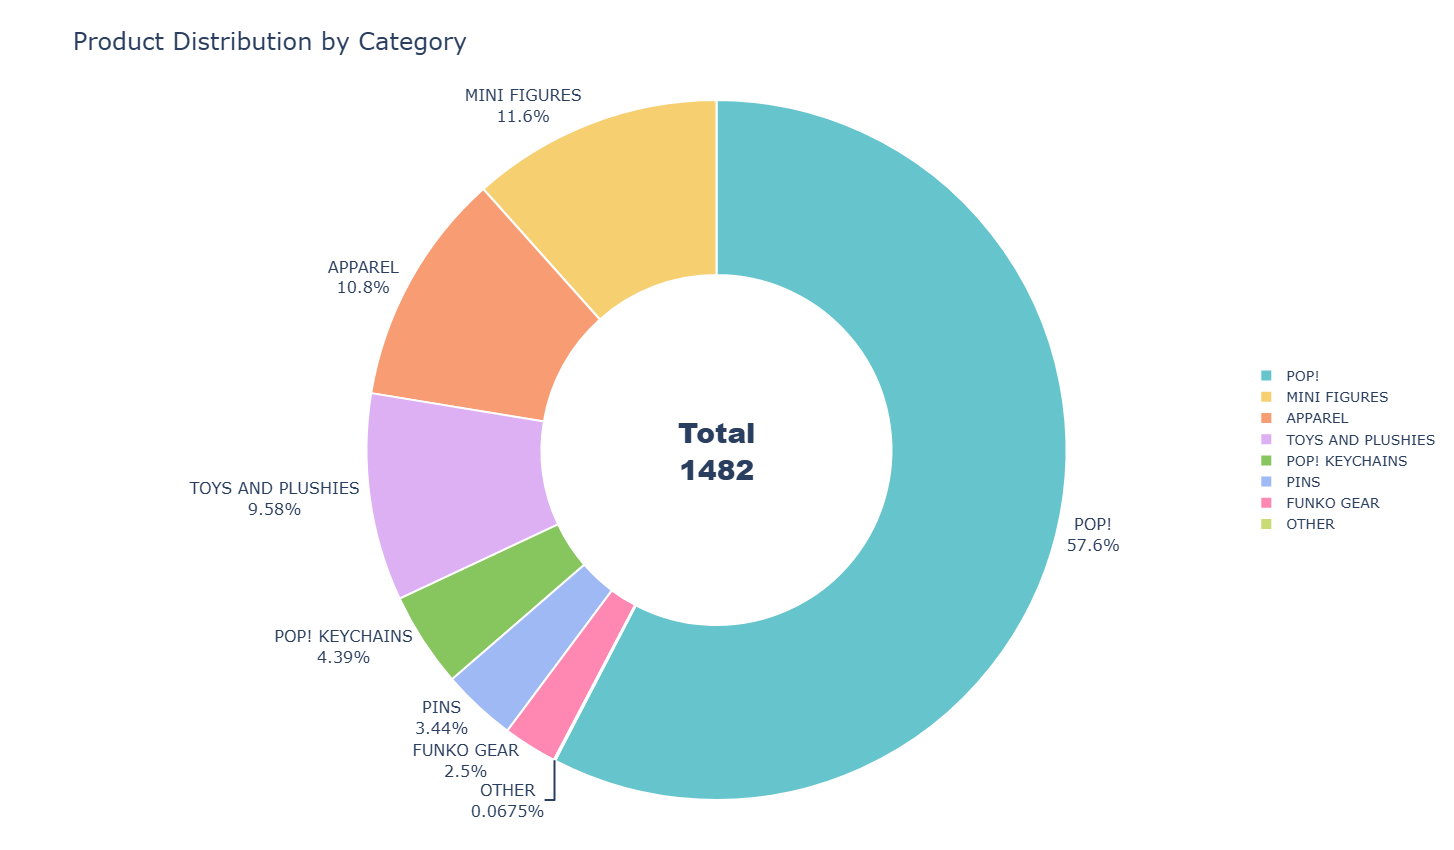

In [27]:
# 1. Directly count the values from the already mapped column
category_counts = df['product_type'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

# 2. Create the Large Donut Chart
fig = px.pie(
    category_counts, 
    values='Count', 
    names='Category', 
    hole=0.5,
    title='Product Distribution by Category',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    # Set a larger default size
    width=1100, 
    height=850  
)

# 3. Optimize labels and layout
fig.update_traces(
    textposition='outside', # Labels outside for better visibility
    textinfo='percent+label',
    textfont_size=16,       # Larger font for clarity
    marker=dict(line=dict(color='#FFFFFF', width=2))
)

fig.update_layout(
    # Center text with total sum
    annotations=[dict(
        text=f'Total<br>{category_counts["Count"].sum()}', 
        x=0.5, y=0.5, 
        font_size=28, 
        showarrow=False,
        font_family="Arial Black"
    )],
    # Legend styling
    legend=dict(
        font=dict(size=14),
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.1
    ),
    title_font_size=24,
    margin=dict(l=50, r=200, t=100, b=50) # Extra right margin for labels
)

fig.show()

In [28]:
# lets check all unique licenses

# 1. Flatten all lists in the 'license' column into a single list
# 2. Use set() to get unique values and sorted() to order them alphabetically
all_licenses = [item for sublist in df['license'] for item in sublist]
unique_licenses = sorted(list(set(all_licenses)))

# Display the results
print(f"Total unique licenses found: {len(unique_licenses)}")
print(unique_licenses)

Total unique licenses found: 345
['101 Dalmatians', 'AC/DC', 'ASPCA', 'Aaliyah', 'Adventure Time', 'Aladdin', 'Alice in Wonderland', 'Alien', 'American History', 'Apex Legends', 'Attack on Titan', 'Avatar The Last Airbender', 'Avengers', 'Avengers Endgame', 'Back to the Future', 'Bakugan', 'Batgirl', 'Batman', 'Baymax', 'Beauty and the Beast', 'Beetlejuice', 'Black Clover', 'Bob Ross', "Bob's Big Boy", 'Boba Fett', 'Boo Hollow', 'Boruto: Naruto Next Generations', 'Boxing', 'Boyz II Men', "Bram Stoker's Dracula", 'Bret Michaels', 'Bride of Chucky', 'Britney Spears', 'Candyman', "Cap 'n Crunch", 'Captain America', 'Captain Marvel', 'Carnage', 'Carrie', 'Catwoman', 'Cheetos', "Child's Play", 'Chilling Adventures of Sabrina', 'Chris Stapleton', 'Cinderella', 'Clone Wars', 'ClownSpy', 'Coca-Cola', 'Cool Runnings', 'Cow and Chicken', 'Cowboy Bebop', 'Creepshow', 'Cricket', 'Cruella', 'Cypress Hill', 'DC Comics Bombshells', 'DC Imperial Palace', 'DCeased', 'DJ Khaled', 'Daredevil', 'Deadmau5'

In [29]:
# lets inspect their repeats

# 1. Flatten the lists and count occurrences
# .explode() creates a new row for every license in the list
license_counts = df['license'].explode().value_counts().reset_index()
license_counts.columns = ['License', 'Count']

# 2. Sort by count and take the top 345 for better visualization
top_licenses = license_counts.head(345)

# 3. Create a horizontal bar chart
fig = px.bar(
    top_licenses, 
    x='Count', 
    y='License', 
    orientation='h',  # Horizontal orientation
    title='Licenses',
    labels={'Count': 'Number of Products', 'License': 'License Name'},
    color='Count',    # Colors bars based on frequency
    color_continuous_scale='Viridis',
    width=1000,
    height=800
)

# 4. Improve layout for readability
fig.update_layout(
    yaxis={'categoryorder':'total ascending'}, # Shows the biggest at the top
    title_font_size=24,
    margin=dict(l=200) # Give more space on the left for long license names
)

fig.show()

In [30]:
prices = set(df["price"])
prices

{2.5,
 5.0,
 6.0,
 7.0,
 8.0,
 9.0,
 10.0,
 11.0,
 12.0,
 13.0,
 14.0,
 15.0,
 16.0,
 17.0,
 17.5,
 18.0,
 20.0,
 23.0,
 25.0,
 30.0,
 35.0,
 40.0,
 45.0,
 50.0,
 60.0,
 65.0,
 70.0,
 100.0,
 105.0}

Above we see prices, that looks Manufacturer’s Suggested Retail Price, so we can't use them as rarity factor. At least we can calculate and visualisate average MSRP by product type

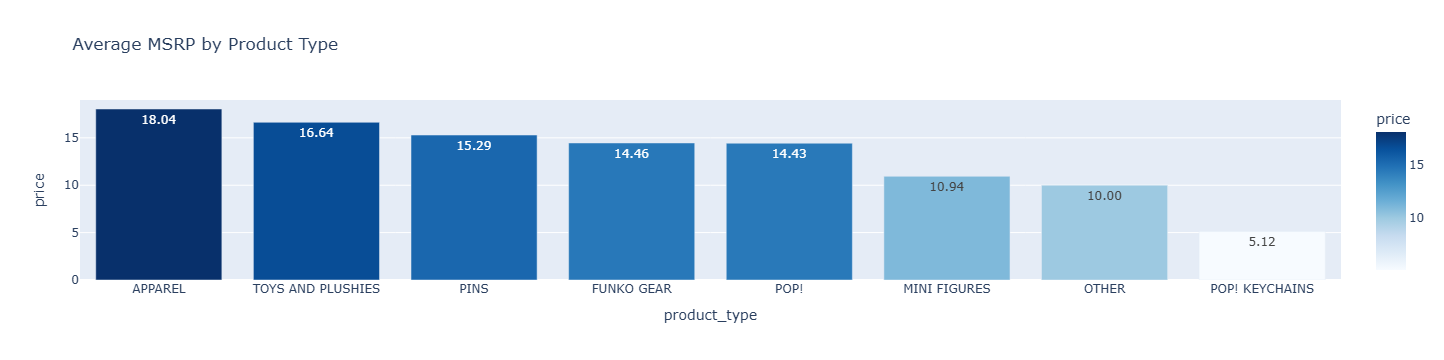

In [31]:
avg_prices = df.groupby('product_type')['price'].mean().reset_index().sort_values('price', ascending=False)

fig_avg = px.bar(
    avg_prices,
    x='product_type',
    y='price',
    text_auto='.2f',
    title='Average MSRP by Product Type',
    color='price',
    color_continuous_scale='Blues'
)
fig_avg.show()

In [32]:
# Write the final cleaned file
df.to_csv('final_funko.csv', index=False, encoding='utf-8-sig')